## Лабораторная работа: определение музыкальных трезвучий

Выполнила: Перминова Анастасия, М4121

* Загрузка библиотек

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks
import librosa
from IPython.display import Audio

* Загрузка и предварительный анализ сигнала "DTLab9.wav"

In [38]:
# загружаем аудиофайл
sample_rate, audio_data = wavfile.read('DTLab9.wav')

# выводим параметры сигнала
print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Длина сигнала: {len(audio_data)} отсчетов")
print(f"Длительность: {len(audio_data) / sample_rate:.2f} сек")
print(f"Тип данных: {audio_data.dtype}")

Audio(audio_data, rate=sample_rate)

Частота дискретизации: 16000 Гц
Длина сигнала: 80000 отсчетов
Длительность: 5.00 сек
Тип данных: int16


* Вычисление амплитудного спектра

In [39]:
# задаем параметры для спектрального анализа
n_fft = 8192  # размер окна ДПФ (дано в условии)
hop_length = n_fft // 2  # шаг между окнами (перекрытие - 50%)

# вычисляем спектрограмму, используя librosa
stft = librosa.stft(audio_data.astype(float), 
                    n_fft=n_fft, 
                    hop_length=hop_length)

# получаем амплитудный спектр
amplitude_spectrum = np.abs(stft)

# усредняем по времени
mean_amplitude_spectrum = np.mean(amplitude_spectrum, axis=1)

# переводим в логарифмическую шкалу
log_spectrum = 20 * np.log10(mean_amplitude_spectrum + 1e-10)  # +1e-10 чтобы избежать log(0)

# вычисляем соответствующие частоты для ДПФ
frequencies = librosa.fft_frequencies(sr=sample_rate, n_fft=n_fft)

* Визуализация спектра

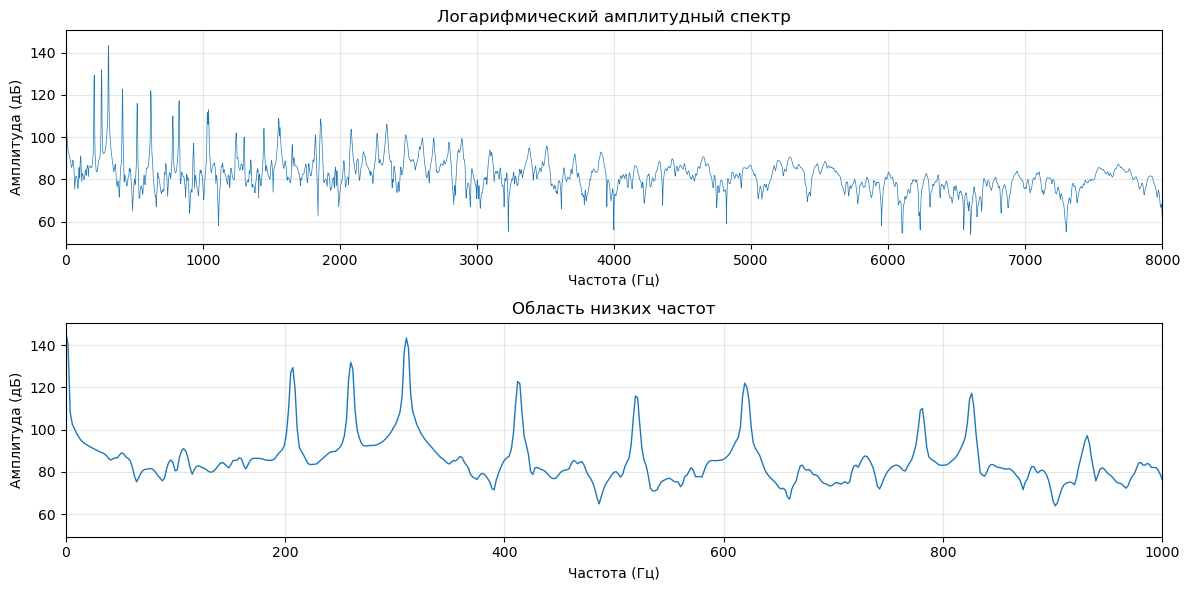

In [40]:
# полный спектр
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(frequencies, log_spectrum, linewidth=0.5)
plt.title('Логарифмический амплитудный спектр')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 8000)

# для низких частот
plt.subplot(2, 1, 2)
plt.plot(frequencies, log_spectrum, linewidth=1)
plt.title('Область низких частот')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (дБ)')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

* Поиск основных частот трезвучия и проверка обертонов

In [41]:
# ограничиваем поиск диапазоном 50-1000 Гц
min_freq_idx = np.argmax(frequencies >= 50)
max_freq_idx = np.argmax(frequencies >= 1000)

# уменьшаем область поиска, "вырезав" части спектра и частотной оси
search_spectrum = log_spectrum[min_freq_idx:max_freq_idx]
search_frequencies = frequencies[min_freq_idx:max_freq_idx]

# находим пики в спектре
peaks, properties = find_peaks(search_spectrum, 
                               height=np.max(search_spectrum) - 20,  # пики не ниже 20 дБ от максимума
                               distance=10,  # минимальное расстояние между пиками
                               prominence=5)  # минимальное "возвышение" пика над соседними, чтобы избежать двойных

# отбираем 3 самых значительных пика
if len(peaks) > 0:
    peak_indices = peaks[np.argsort(search_spectrum[peaks])[::-1]]  # сортируем по амплитуде
    
    # берем 3 самых высоких пика
    n_peaks = min(3, len(peak_indices))
    main_peaks = peak_indices[:n_peaks]
    
    # сортируем по частоте (от низкой к высокой)
    main_peaks = sorted(main_peaks, key=lambda x: search_frequencies[x])
    
    # получаем частоты пиков
    detected_frequencies = search_frequencies[main_peaks]
    
    print(f"\nНайдено {len(detected_frequencies)} основных частоты:")
    for i, freq in enumerate(detected_frequencies, 1):
        print(f"  F{i}: {freq:.2f} Гц")

    print("\nПроверка обертонов:")
    
    for i, base_freq in enumerate(detected_frequencies, 1):
        harmonic_2f = 2 * base_freq  # ищем первую гармонику
        harmonic_idx = np.argmin(np.abs(frequencies - harmonic_2f)) # находим ближайший к гармонике частотный бин
        
        # проверяем, есть ли пик рядом с гармоникой
        # берем срез массива от harmonic_idx-10 до harmonic_idx+10, чтобы оценить фоновый уровень вокруг гармоники
        # 3 дБ - порог, чтобы отличить тон от шума
        harmonic_present = log_spectrum[harmonic_idx] > np.mean(log_spectrum[harmonic_idx-10:harmonic_idx+10]) + 3
            
        print(f"  F{i}: {base_freq:.2f} Гц >> 2F{i}: {harmonic_2f:.2f} Гц - {'гармоника есть' if harmonic_present else 'гармоника слабая'}")

    print('\n')
    
    f1, f2, f3 = detected_frequencies
        
    # определяем интервалы по формуле
    interval1 = 12 * np.log2(f2 / f1)
    interval2 = 12 * np.log2(f3 / f2)
        
    if (3.9 <= interval1 <= 4.1) and (2.9 <= interval2 <= 3.1):
        print("Предполагаемое трезвучие - мажорное")
        print(f"(большая терция + малая терция)")
        
    elif (2.9 <= interval1 <= 3.1) and (3.9 <= interval2 <= 4.1):
        print("Предполагаемое трезвучие - минорное")
        print(f"(малая терция + большая терция)")


Найдено 3 основных частоты:
  F1: 207.03 Гц
  F2: 259.77 Гц
  F3: 310.55 Гц

Проверка обертонов:
  F1: 207.03 Гц >> 2F1: 414.06 Гц - гармоника есть
  F2: 259.77 Гц >> 2F2: 519.53 Гц - гармоника есть
  F3: 310.55 Гц >> 2F3: 621.09 Гц - гармоника есть


Предполагаемое трезвучие - мажорное
(большая терция + малая терция)
